In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  # points to src/systematic_trading

from data.minute_data_loader import get_minute_quotes
import datetime as dt
import pandas as pd


traded_instruments = [
    "AUDUSD",
    "EURUSD",
    "GBPUSD",
    "EURGBP",
    "EURJPY",
    "USDJPY",
    "USDCHF",
    "EURCHF",
    "USDCAD",
    "USDZAR",
    "USDPLN",
    "EURPLN",
    "USDNOK",
    "USDSEK",
    "EURNOK",
    "EURSEK",
    "USDSGD",
    "USDMXN",
    "NZDUSD",
]

marketdata_instruments = traded_instruments # + ["UDXUSD", "XAUUSD"]

minute_dict = get_minute_quotes(
    marketdata_instruments,
    dt.date(2023, 1, 2),
    dt.date(2026, 1, 31),
)

In [226]:
import importlib
import strategy.factor_mean_reversion_strategy as fmrs

importlib.reload(fmrs)
from strategy.factor_mean_reversion_strategy import FactorMeanReversionStrategy

strategy = FactorMeanReversionStrategy(
    instruments=traded_instruments,
    close_price_dict=minute_dict,
    hyper_param_dict={
        "zs_entry_threshold": 2,
        "zs_exit_threshold": 0,
        "spread_entry_multiplier": 5,
        "residual_rolling_lookback": pd.Timedelta(minutes=120),
        "n_components": 1
    },
)

In [230]:
from trading.aggressive_trader import AggressiveTrader

#signals = strategy.generate_signals2()
#signals_nohedge = strategy.generate_signals()
signals_fn = strategy.generate_signals3()

In [231]:
trader = AggressiveTrader(traded_instruments, minute_dict, signals_fn)

In [232]:
from analytics.markout import Markout
markout = Markout(trader, minute_dict)
markout.calculate_markout(plot=True,
                          instruments=['USDZAR'],
                          start_date=dt.date(2025, 6, 1),
                          end_date=dt.date(2025, 7, 2),
                          T_before=pd.Timedelta(minutes=240),
                          T_after=pd.Timedelta(minutes=240))

,markout,weight
time_from_trade,,
-1 days +20:00:00,-0.000054,149.581381
-1 days +20:01:00,-0.000070,149.581381
-1 days +20:02:00,-0.000084,149.581381
-1 days +20:03:00,-0.000071,149.581381
-1 days +20:04:00,-0.000091,149.581381
...,...,...
0 days 03:56:00,-0.000112,151.117261
0 days 03:57:00,-0.000090,151.117261
0 days 03:58:00,-0.000069,151.117261


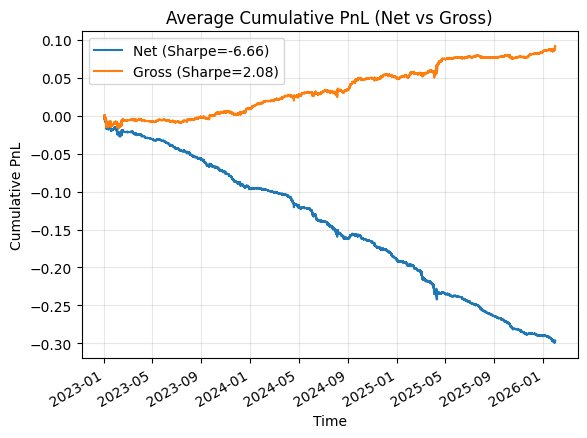

In [233]:
import numpy as np

net_pnl_dict = trader.generate_net_pnl()
gross_pnl_dict = trader.generate_gross_pnl()

net_df = pd.DataFrame(net_pnl_dict).fillna(0.0)
gross_df = pd.DataFrame(gross_pnl_dict).fillna(0.0)

avg_net = net_df.mean(axis=1)
avg_gross = gross_df.mean(axis=1)

net_sharpe = np.sqrt(252 * 24 * 60) * avg_net.mean() / avg_net.std() if avg_net.std() != 0 else np.nan
gross_sharpe = (
    np.sqrt(252 * 24 * 60) * avg_gross.mean() / avg_gross.std() if avg_gross.std() != 0 else np.nan
)

ax = avg_net.cumsum().plot(label=f"Net (Sharpe={net_sharpe:.2f})")
avg_gross.cumsum().plot(ax=ax, label=f"Gross (Sharpe={gross_sharpe:.2f})")

ax.set_title("Average Cumulative PnL (Net vs Gross)")
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
ax.grid(True, alpha=0.3)


In [176]:
from analytics.performance_report import PerformanceReport

report = PerformanceReport(traded_instruments, trader)

report.generate_performance_report()

,Sharpe_Net,Sharpe_Gross,AvgTradesPerDay,MaxDrawdown,WorstDayPnL,AvgNetPnLPerTrade,AvgGrossPnLPerTrade,AvgPosDur,MedPosDur,Q10PosDur,Q90PosDur
AUDUSD,-0.166432,0.079735,0.229333,-0.065459,-0.043257,-0.000078,0.000037,0 days 07:24:50.232558,0 days 04:32:00,0 days 00:09:00,0 days 14:16:48
EURUSD,-0.673946,-0.475636,0.332444,-0.061526,-0.017311,-0.00013,-0.00009,0 days 06:53:24.705882,0 days 02:23:00,0 days 00:09:00,0 days 12:32:00
GBPUSD,-0.057308,0.371872,0.38537,-0.032646,-0.018846,-0.00001,0.000063,0 days 07:40:03.888888,0 days 02:57:30,0 days 00:09:00,0 days 14:17:00
EURGBP,-1.127003,-0.256576,0.398577,-0.06457,-0.010555,-0.000127,-0.000027,0 days 06:46:38.303571,0 days 01:28:30,0 days 00:09:00,0 days 12:04:06
EURJPY,0.002538,0.348886,0.313725,-0.050727,-0.010116,0.000001,0.000092,0 days 07:21:37.840909,0 days 01:59:00,0 days 00:09:00,0 days 13:58:00
USDJPY,-0.352736,-0.163872,0.330373,-0.090363,-0.014054,-0.000114,-0.000053,0 days 09:32:24.193548,0 days 03:06:30,0 days 00:09:00,0 days 20:17:30
USDCHF,-0.564592,-0.098701,0.345196,-0.114334,-0.02809,-0.00016,-0.000027,0 days 07:24:33.092783,0 days 02:58:00,0 days 00:09:00,0 days 15:14:06
EURCHF,-0.648623,0.311446,0.427427,-0.059469,-0.019106,-0.000102,0.000048,0 days 06:45:34,0 days 02:03:00,0 days 00:09:00,0 days 12:28:35.999999
USDCAD,0.017822,0.582268,0.327402,-0.028666,-0.006955,0.000003,0.00009,0 days 10:33:20.869565,0 days 04:04:30,0 days 00:09:00,2 days 02:55:30
USDZAR,-2.220404,0.014418,0.427556,-0.350614,-0.02414,-0.000673,0.000003,0 days 06:27:29.750000,0 days 02:36:30,0 days 00:09:00,0 days 11:59:18


In [127]:
from analytics.plot_daily_recap import plot_daily_recap

instrument = "USDPLN"
date_range = (dt.date(2025, 9, 2), dt.date(2025, 9, 30))
close_price_df = minute_dict[instrument]
plot_daily_recap(instrument, date_range, close_price_df, strategy, trader)

In [ ]:
import importlib
import analytics.hyperparam_optimizer as ho

importlib.reload(ho)

import pandas as pd
from analytics.hyperparam_optimizer import optimize_factor_mean_reversion_hyperparams

param_grid = {
    "zs_entry_threshold": [1.0, 2.0, 3.0],
    "zs_exit_threshold": [-0.5, 0.0],
    "spread_entry_multiplier": [5.0, 10.0],
    "residual_rolling_lookback": [
        #pd.Timedelta("10min"),
        pd.Timedelta("20min"),
        #pd.Timedelta("30min"),
        #pd.Timedelta("45min"),
        #pd.Timedelta("1h"),
        pd.Timedelta("2h"),
        #pd.Timedelta("3h"),
        pd.Timedelta("4h"),
        pd.Timedelta("12h"),
    ],
    "n_components" : [1, 2],
}

result = optimize_factor_mean_reversion_hyperparams(
    instruments=traded_instruments,
    close_price_dict=minute_dict,
    param_grid=param_grid,
    log_path="hyperparam_trials.csv",
    checkpoint_every=5,
)

print(result.best_sharpe_by_pair)      # best Sharpe + params per pair
print(result.elapsed_seconds)           # timer harness total runtime
print(result.total_trials, result.log_path)


        best_sharpe_net                                        best_params
AUDUSD         0.057795  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURCHF        -0.071976  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURGBP        -0.058800  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURJPY         0.002538  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURNOK        -0.526196  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURPLN        -0.058230  {'zs_entry_threshold': 1.0, 'zs_exit_threshold...
EURSEK         0.459181  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
EURUSD         0.227179  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
GBPUSD         0.250445  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
NZDUSD        -0.302769  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
USDCAD         0.469017  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
USDCHF        -0.558381  {'zs_entry_threshold': 3.0, 'zs_exit_threshold...
USDJPY        -0.287224  

In [143]:
result.best_sharpe_by_pair.to_csv('tmp.csv')

In [145]:
tmp = pd.read_csv('hyperparam_trials.csv')

In [ ]:
x = tmp[
    (tmp["AUDUSD__AvgTradesPerDay"] > 1)
    & (tmp["AUDUSD__AvgTradesPerDay"] < 10)
    & (tmp["AUDUSD__Sharpe_Net"] > 0)
]
names = ["Sharpe_Net", "Sharpe_Gross", "AvgTradesPerDay", "MaxDrawdown", "WorstDayPnL", "AvgNetPnLPerTrade", "AvgGrossPnLPerTrade",	"AvgPosDur", "MedPosDur", "Q10PosDur", "Q90PosDur"]

["param__zs_entry_threshold", "param__zs_exit_threshold", "param__spread_entry_multiplier", "param__residual_rolling_lookback"] + ["AUDUSD__" + a for a in names]

['param__zs_entry_threshold',
 'param__zs_exit_threshold',
 'param__spread_entry_multiplier',
 'param__residual_rolling_lookback',
 'AUDUSD__Sharpe_Net',
 'AUDUSD__Sharpe_Gross',
 'AUDUSD__AvgTradesPerDay',
 'AUDUSD__MaxDrawdown',
 'AUDUSD__WorstDayPnL',
 'AUDUSD__AvgNetPnLPerTrade',
 'AUDUSD__AvgGrossPnLPerTrade',
 'AUDUSD__AvgPosDur',
 'AUDUSD__MedPosDur',
 'AUDUSD__Q10PosDur',
 'AUDUSD__Q90PosDur']

In [146]:
names = ["Sharpe_Net", "Sharpe_Gross", "AvgTradesPerDay", "MaxDrawdown", "WorstDayPnL", "AvgNetPnLPerTrade", "AvgGrossPnLPerTrade",	"AvgPosDur", "MedPosDur", "Q10PosDur", "Q90PosDur"]
r = []

for instrument in traded_instruments:
    instrument_names = [instrument + "__" + a for a in names]
    x = tmp[(tmp[instrument + '__AvgTradesPerDay']>1) &(tmp[instrument + '__Sharpe_Net']>0.3)]
    x = x[["param__zs_entry_threshold", "param__zs_exit_threshold", "param__spread_entry_multiplier", "param__residual_rolling_lookback"] + instrument_names]
    x = x.rename(columns=dict(zip(instrument_names, names)))
    x["sym"] = instrument
    
    r.append(x)

In [147]:
r

[Empty DataFrame
 Columns: [param__zs_entry_threshold, param__zs_exit_threshold, param__spread_entry_multiplier, param__residual_rolling_lookback, Sharpe_Net, Sharpe_Gross, AvgTradesPerDay, MaxDrawdown, WorstDayPnL, AvgNetPnLPerTrade, AvgGrossPnLPerTrade, AvgPosDur, MedPosDur, Q10PosDur, Q90PosDur, sym]
 Index: [],
 Empty DataFrame
 Columns: [param__zs_entry_threshold, param__zs_exit_threshold, param__spread_entry_multiplier, param__residual_rolling_lookback, Sharpe_Net, Sharpe_Gross, AvgTradesPerDay, MaxDrawdown, WorstDayPnL, AvgNetPnLPerTrade, AvgGrossPnLPerTrade, AvgPosDur, MedPosDur, Q10PosDur, Q90PosDur, sym]
 Index: [],
 Empty DataFrame
 Columns: [param__zs_entry_threshold, param__zs_exit_threshold, param__spread_entry_multiplier, param__residual_rolling_lookback, Sharpe_Net, Sharpe_Gross, AvgTradesPerDay, MaxDrawdown, WorstDayPnL, AvgNetPnLPerTrade, AvgGrossPnLPerTrade, AvgPosDur, MedPosDur, Q10PosDur, Q90PosDur, sym]
 Index: [],
 Empty DataFrame
 Columns: [param__zs_entry_thres